All libraries imported successfully!

Dataset loaded successfully!
Number of rows: 1000
Number of columns: 8

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Information:
<class 'panda

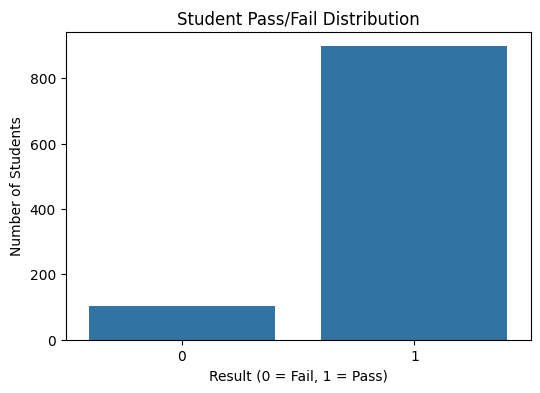


Data after encoding:
   math score  reading score  writing score  gender_male  \
0          72             72             74        False   
1          69             90             88        False   
2          90             95             93        False   
3          47             57             44         True   
4          76             78             75         True   

   race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                    True                   False                   False   
1                   False                    True                   False   
2                    True                   False                   False   
3                   False                   False                   False   
4                   False                    True                   False   

   race/ethnicity_group E  parental level of education_bachelor's degree  \
0                   False                                           True   
1 

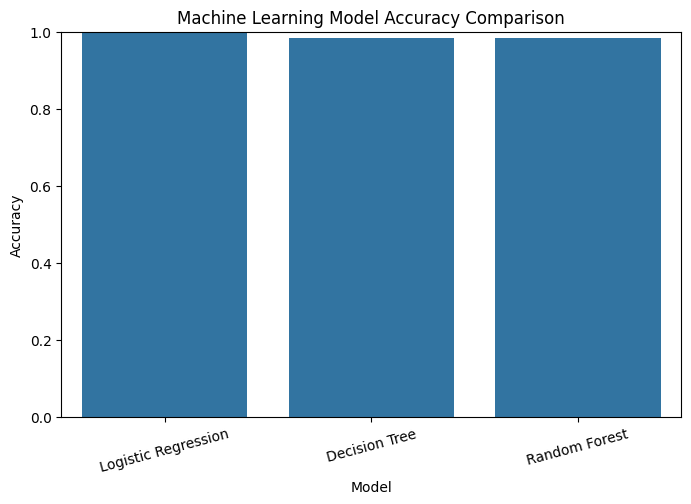

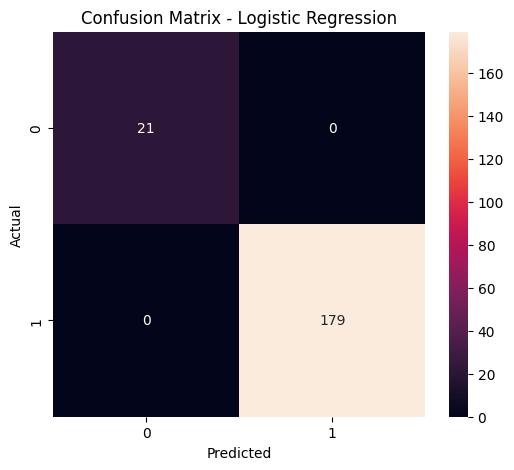

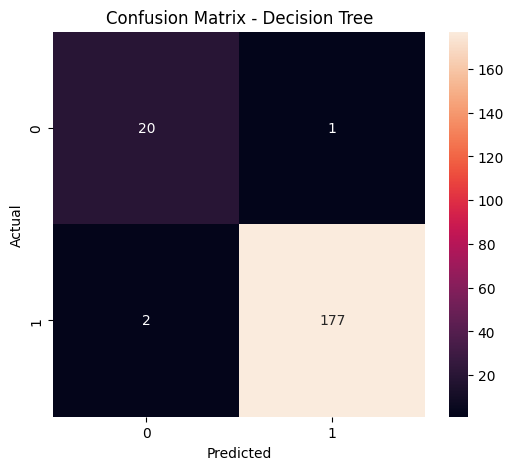

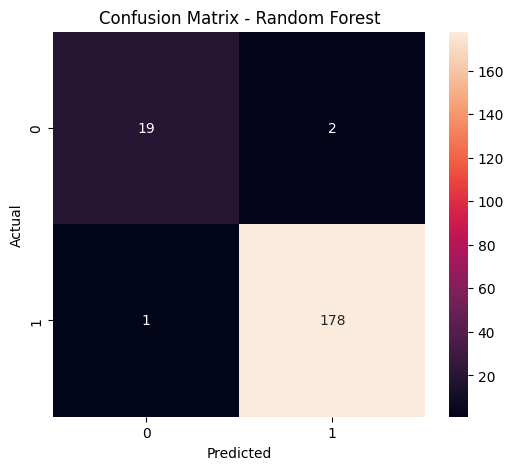

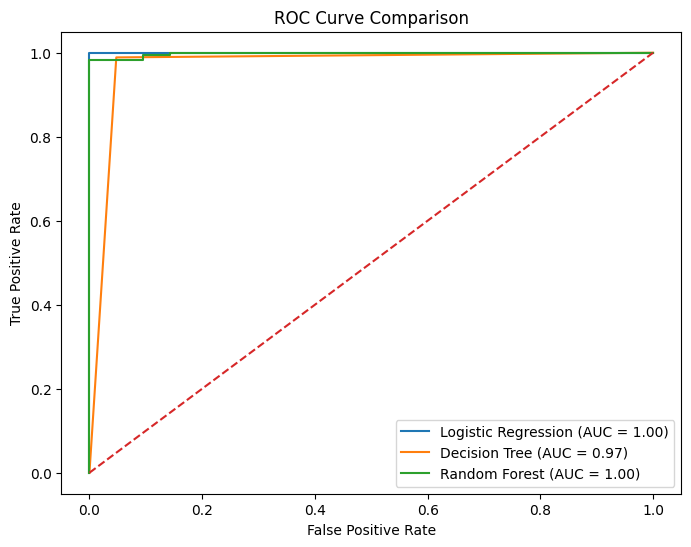


AUC SCORES
                 Model       AUC
0  Logistic Regression  1.000000
1        Decision Tree  0.970604
2        Random Forest  0.998138

FEATURE IMPORTANCE
                                          Feature  Importance
1                                   reading score    0.371831
2                                   writing score    0.347919
0                                      math score    0.199927
13                                 lunch_standard    0.014148
3                                     gender_male    0.011413
12   parental level of education_some high school    0.007535
4                          race/ethnicity_group B    0.007422
14                   test preparation course_none    0.007361
8   parental level of education_bachelor's degree    0.006079
11       parental level of education_some college    0.005704


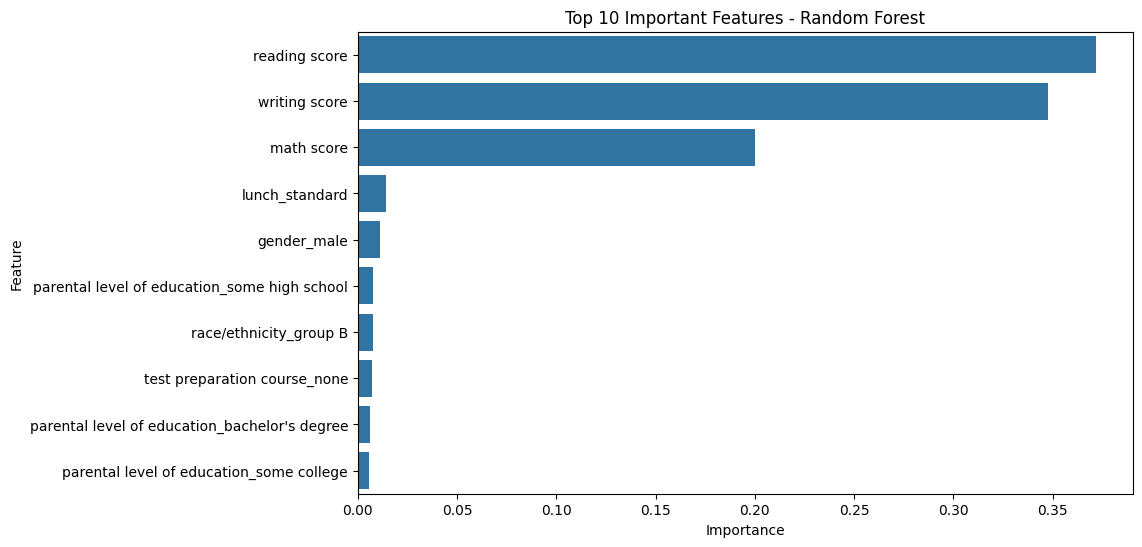


BEST MODEL
Best Model: Logistic Regression
Best Accuracy: 100.0 %

SAMPLE STUDENT PREDICTION
Prediction: PASS
Probability of Passing: 100.0 %

PROJECT COMPLETED
Logistic Regression Accuracy: 100.0 %
Decision Tree Accuracy: 98.5 %
Random Forest Accuracy: 98.5 %

Best Model: Logistic Regression


In [1]:
# ============================================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# STUDENTS PERFORMANCE DATASET
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("StudentsPerformance.csv")

print("\nDataset loaded successfully!")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


# ============================================================
# 3. DISPLAY DATA
# ============================================================

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 4. CHECK DATA INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()


# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 6. BASIC STATISTICS
# ============================================================

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 7. CREATE TOTAL SCORE
# ============================================================

df["total_score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
)

print("\nTotal score created successfully!")

print(df[[
    "math score",
    "reading score",
    "writing score",
    "total_score"
]].head())


# ============================================================
# 8. CREATE TARGET VARIABLE
# ============================================================
# Passing criteria:
# Average score >= 50 = PASS
# Average score < 50 = FAIL
#
# 1 = Pass
# 0 = Fail


df["average_score"] = df["total_score"] / 3

df["pass"] = np.where(
    df["average_score"] >= 50,
    1,
    0
)

print("\nPass/Fail distribution:")
print(df["pass"].value_counts())


# ============================================================
# 9. VISUALIZE PASS/FAIL DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    x="pass",
    data=df
)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Result (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 10. SELECT FEATURES
# ============================================================

features = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score",
    "writing score"
]

X = df[features].copy()

y = df["pass"]


# ============================================================
# 11. CONVERT CATEGORICAL DATA INTO NUMBERS
# ============================================================

X = pd.get_dummies(
    X,
    columns=[
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course"
    ],
    drop_first=True
)

print("\nData after encoding:")
print(X.head())


# ============================================================
# 12. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
# 13. LOGISTIC REGRESSION
# ============================================================

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Accuracy:",
      round(logistic_accuracy * 100, 2),
      "%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)


# ============================================================
# 14. DECISION TREE
# ============================================================

print("\n==============================")
print("DECISION TREE")
print("==============================")

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Accuracy:",
      round(tree_accuracy * 100, 2),
      "%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tree
    )
)


# ============================================================
# 15. RANDOM FOREST
# ============================================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

y_pred_forest = random_forest.predict(
    X_test
)

forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

print("Accuracy:",
      round(forest_accuracy * 100, 2),
      "%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_forest
    )
)


# ============================================================
# 16. COMPARE ALL MODELS
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results)


# ============================================================
# 17. MODEL ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Machine Learning Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()


# ============================================================
# 18. CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================================
# 19. CONFUSION MATRIX - DECISION TREE
# ============================================================

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix - Decision Tree"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================================
# 20. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix - Random Forest"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================================
# 21. ROC CURVE - LOGISTIC REGRESSION
# ============================================================

prob_logistic = (
    logistic_model.predict_proba(X_test)[:, 1]
)

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    prob_logistic
)

auc_logistic = roc_auc_score(
    y_test,
    prob_logistic
)


# ============================================================
# 22. ROC CURVE - DECISION TREE
# ============================================================

prob_tree = (
    decision_tree.predict_proba(X_test)[:, 1]
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    prob_tree
)

auc_tree = roc_auc_score(
    y_test,
    prob_tree
)


# ============================================================
# 23. ROC CURVE - RANDOM FOREST
# ============================================================

prob_forest = (
    random_forest.predict_proba(X_test)[:, 1]
)

fpr_forest, tpr_forest, _ = roc_curve(
    y_test,
    prob_forest
)

auc_forest = roc_auc_score(
    y_test,
    prob_forest
)


# ============================================================
# 24. PLOT ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.2f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.2f})"
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {auc_forest:.2f})"
)

# Random guessing line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


# ============================================================
# 25. AUC COMPARISON
# ============================================================

auc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "AUC": [
        auc_logistic,
        auc_tree,
        auc_forest
    ]
})

print("\n==============================")
print("AUC SCORES")
print("==============================")

print(auc_results)


# ============================================================
# 26. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,

    "Importance":
        random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance.head(10))


# ============================================================
# 27. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features - Random Forest"
)

plt.show()


# ============================================================
# 28. FIND BEST MODEL
# ============================================================

best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("\n==============================")
print("BEST MODEL")
print("==============================")

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Best Accuracy:",
    round(
        best_model["Accuracy"] * 100,
        2
    ),
    "%"
)


# ============================================================
# 29. SAMPLE STUDENT PREDICTION
# ============================================================

# Create a sample student using the original categories

sample = pd.DataFrame({
    "gender": ["male"],
    "race/ethnicity": ["group C"],
    "parental level of education": ["some college"],
    "lunch": ["standard"],
    "test preparation course": ["completed"],
    "math score": [75],
    "reading score": [70],
    "writing score": [72]
})


# Encode sample in the same way as training data

sample = pd.get_dummies(
    sample,
    columns=[
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course"
    ],
    drop_first=True
)


# Make sure sample has exactly the same columns as X

sample = sample.reindex(
    columns=X.columns,
    fill_value=0
)


# Predict using Random Forest

sample_prediction = random_forest.predict(
    sample
)

sample_probability = random_forest.predict_proba(
    sample
)[0][1]


print("\n==============================")
print("SAMPLE STUDENT PREDICTION")
print("==============================")


if sample_prediction[0] == 1:

    print("Prediction: PASS")

else:

    print("Prediction: FAIL")


print(
    "Probability of Passing:",
    round(sample_probability * 100, 2),
    "%"
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n==============================")
print("PROJECT COMPLETED")
print("==============================")

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

print(
    "Decision Tree Accuracy:",
    round(tree_accuracy * 100, 2),
    "%"
)

print(
    "Random Forest Accuracy:",
    round(forest_accuracy * 100, 2),
    "%"
)

print(
    "\nBest Model:",
    best_model["Model"]
)